# **Wine Quality Prediction**

This project aims to develop a predictive model to determine the quality of wine based on its chemical properties and type (red or white). The dataset contains features such as acidity, residual sugar, chlorides, alcohol content, and others, along with a quality score ranging from 1 to 10, where 10 represents the highest quality.

In [2]:
# Import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# load the dataset
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DataSets/winequality.csv')
df.sample(10)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4334,white,7.3,0.19,0.27,13.90,0.057,45.0,155.0,0.99807,2.94,0.41,8.8,8
4432,white,6.7,0.24,0.26,5.40,0.030,15.0,94.0,0.99045,3.15,0.38,12.7,6
4108,white,6.7,0.28,0.42,3.50,0.035,43.0,105.0,0.99021,3.18,0.38,12.2,6
3888,white,6.0,0.28,0.24,17.80,0.047,42.0,111.0,0.99896,3.10,0.45,8.9,6
2192,white,7.9,0.28,0.41,4.90,0.058,31.0,153.0,0.99660,3.27,0.51,9.7,6
4460,white,6.6,0.18,0.26,17.30,0.051,17.0,149.0,0.99840,3.00,0.43,9.4,6
6334,red,10.0,0.38,0.38,1.60,0.169,27.0,90.0,0.99914,3.15,0.65,8.5,5
2079,white,7.4,0.45,0.32,7.10,0.044,17.0,117.0,0.99620,3.32,0.41,10.4,4
600,white,6.7,0.30,0.35,1.40,0.180,36.0,160.0,0.99370,3.11,0.54,9.4,6
2970,white,8.4,0.31,0.31,0.95,0.021,52.0,148.0,0.99038,2.93,0.32,11.5,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


**Handling Missing values**

In [6]:
# check the number of missing values
df.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [7]:
# Applying Mean Imputation to handling missing values

for col in df.columns:
  if df[col].isnull().sum() > 0:
    df[col] = df[col].fillna(df[col].mean())

df.isnull().sum()

,0
type,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


**Handling Outliers**

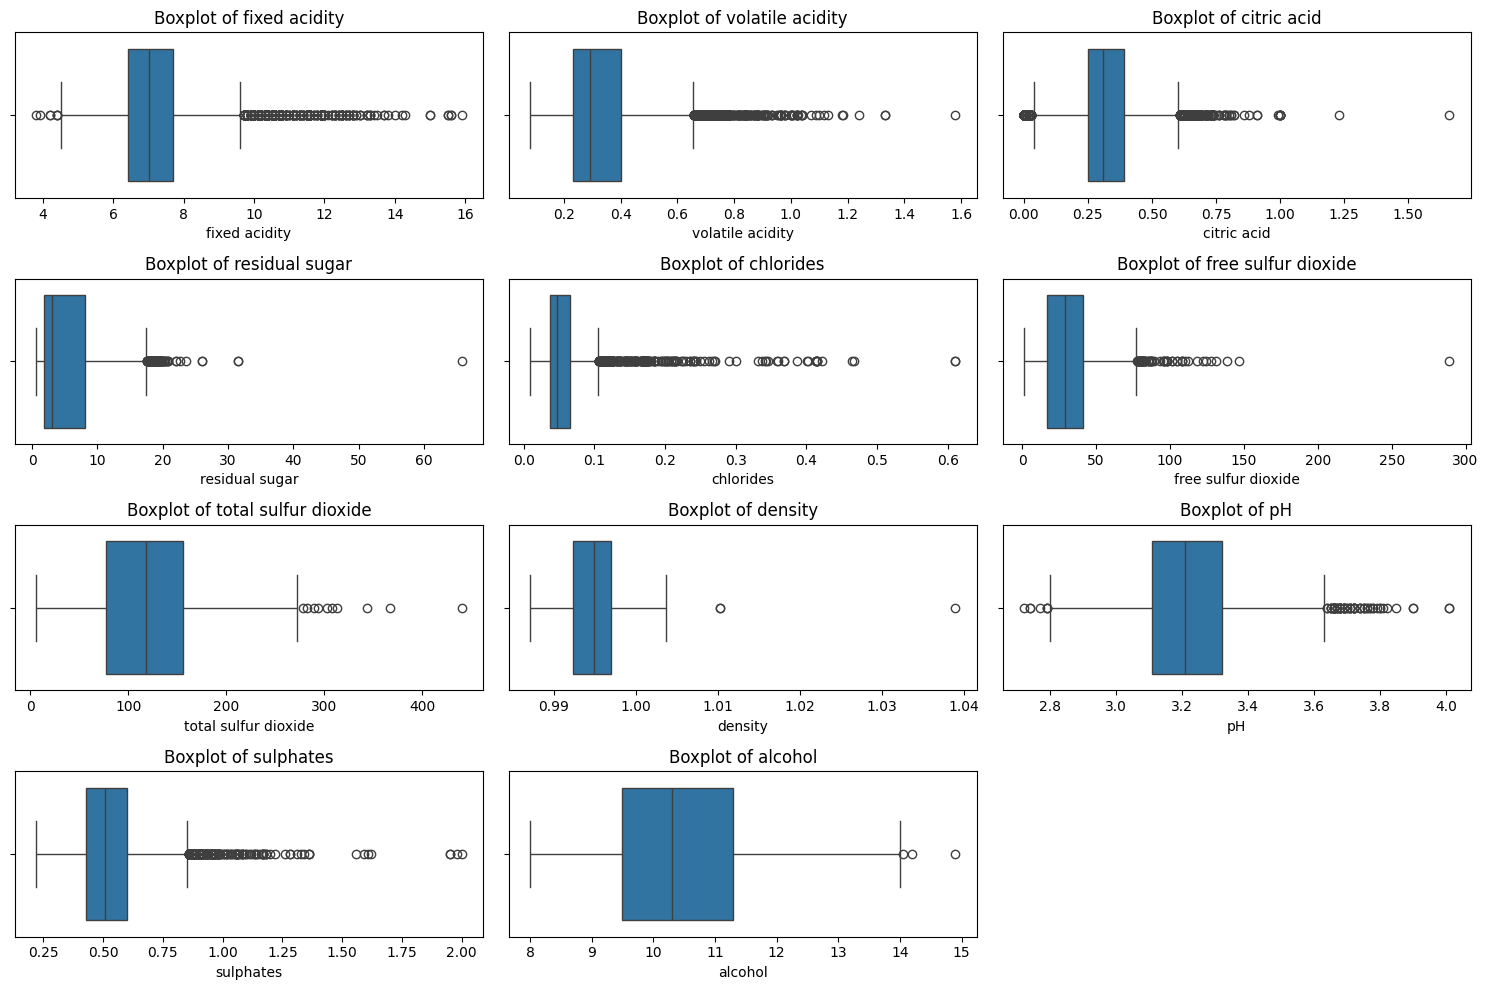

In [8]:
# Plot boxplots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.select_dtypes(include=['float64']).columns):
    plt.subplot(4, 3, i+1)  # Adjust the subplot size as needed
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

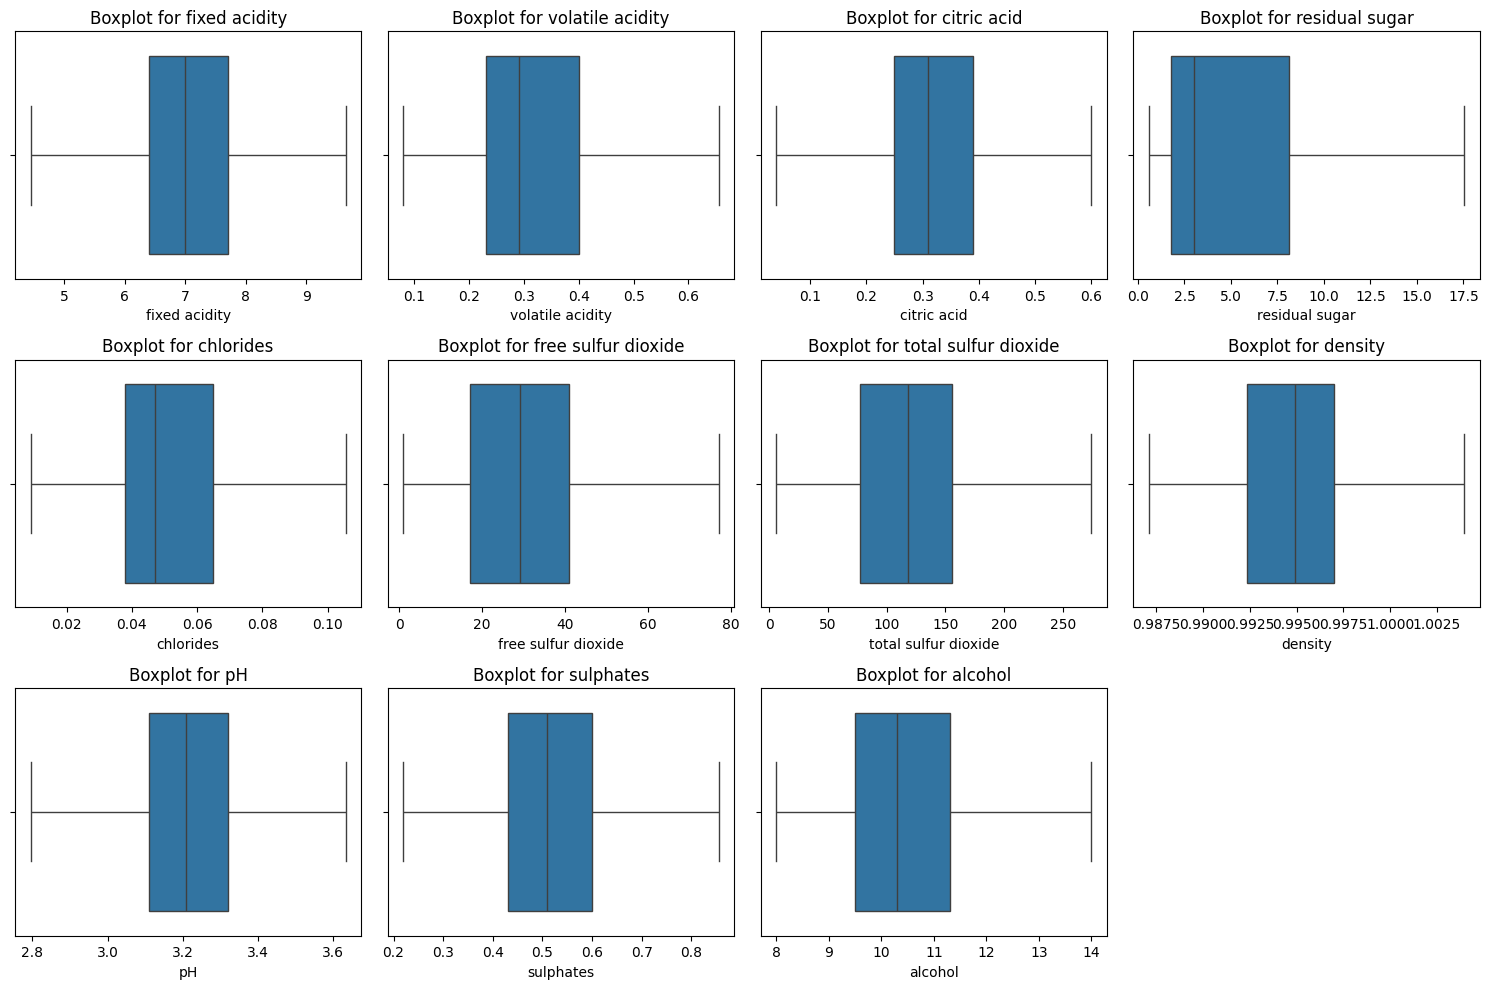

In [9]:
# Function to detect and cap outliers using IQR
def handle_outliers(df):
    for col in df.select_dtypes(include=['float64']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    return df

# Apply outlier handling to the dataset
df = handle_outliers(df)

# plot again
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.select_dtypes(include=['float64']).columns):
    plt.subplot(3, 4, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot for {col}')

plt.tight_layout()
plt.show()

**Data Transformation**

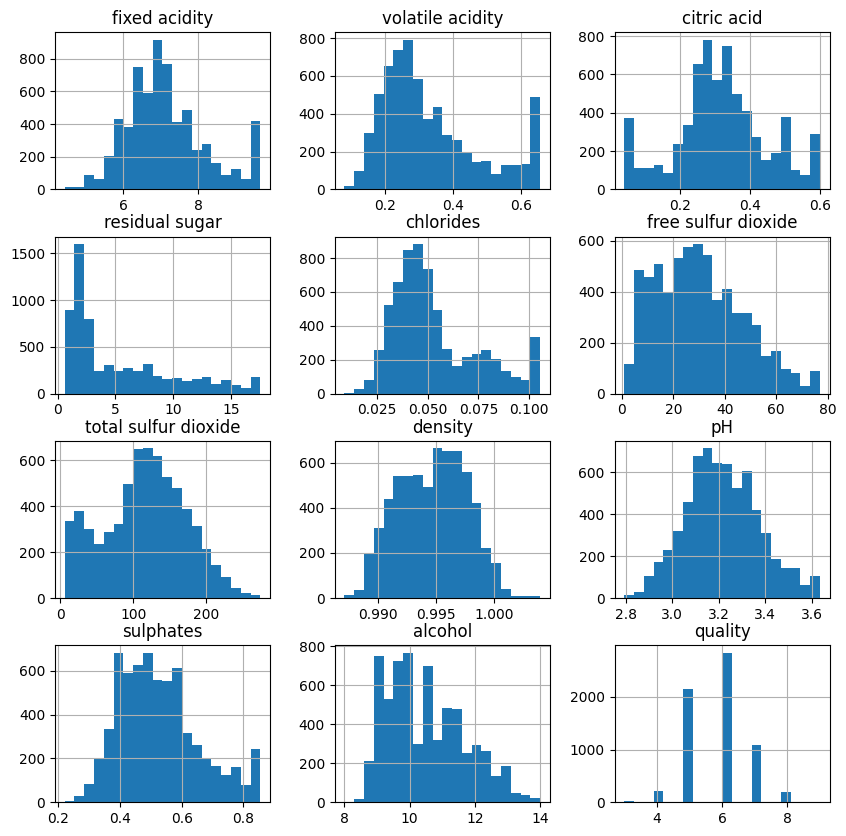

fixed acidity           0.657506
volatile acidity        0.889941
citric acid            -0.000213
residual sugar          1.068609
chlorides               0.932132
free sulfur dioxide     0.500739
total sulfur dioxide   -0.051605
density                -0.015896
pH                      0.258773
sulphates               0.649771
alcohol                 0.562242
dtype: float64


In [10]:
df.hist(bins=20, figsize=(10, 10))
plt.show()

# Check skewness for each numerical column
skewness = df.select_dtypes(include=['float64']).skew()

# Display the skewness values
print(skewness)

In [11]:
# we can identify the 'residual suger' coloumn has right skewness shape.

# Apply log transformation to 'residual sugar' column
logarithm_transformer = FunctionTransformer(np.log1p, validate=True)

# Apply transformation
df['residual sugar'] = logarithm_transformer.fit_transform(df[['residual sugar']])

# Check the skewness again after transformation
print(df['residual sugar'].skew())

0.39418912042469556


**Data Coding**

In [12]:
# Apply label Encoding to the 'type' colomn

# Convert 'type' column to categorical type
df['type'] = df['type'].astype('category')

# Now apply Label Encoding
label_encoder = LabelEncoder()
df['type'] = label_encoder.fit_transform(df['type'])

# Display the transformed 'type' column
print(df['type'].head(5))
print(df['type'].tail(5))

0    1
1    1
2    1
3    1
4    1
Name: type, dtype: int64
6492    0
6493    0
6494    0
6495    0
6496    0
Name: type, dtype: int64


**Feature Scaling**

In [13]:
X = df.drop('quality', axis=1)  # All columns except 'quality'
y = df['quality']  # Target variable

# Apply Min-Max scaling to the numerical columns
scaler = MinMaxScaler()

# Fit and transform the numerical columns
X_scaled = scaler.fit_transform(X)

# Now X_scaled and y are ready to use for model evaluation
print(X_scaled[:10])

[[1.         0.49038462 0.33043478 0.57142857 1.         0.37305699
  0.57894737 0.61080074 0.82408781 0.24404762 0.36220472 0.13333333]
 [1.         0.35576923 0.3826087  0.53571429 0.19812876 0.41450777
  0.17105263 0.46927374 0.40878078 0.60119048 0.42519685 0.25      ]
 [1.         0.70192308 0.34782609 0.64285714 0.65165525 0.42487047
  0.38157895 0.33891993 0.47404331 0.55357143 0.34645669 0.35      ]
 [1.         0.52884615 0.26086957 0.5        0.72691809 0.50777202
  0.60526316 0.67039106 0.5037081  0.4702381  0.28346457 0.31666667]
 [1.         0.52884615 0.26086957 0.5        0.72691809 0.50777202
  0.60526316 0.67039106 0.5037081  0.4702381  0.28346457 0.31666667]
 [1.         0.70192308 0.34782609 0.64285714 0.65165525 0.42487047
  0.38157895 0.33891993 0.47404331 0.55357143 0.34645669 0.35      ]
 [1.         0.33653846 0.4173913  0.21428571 0.65678847 0.37305699
  0.38157895 0.48417132 0.4621774  0.45833333 0.39370079 0.26666667]
 [1.         0.49038462 0.33043478 0.5714

**Class Imbalance**

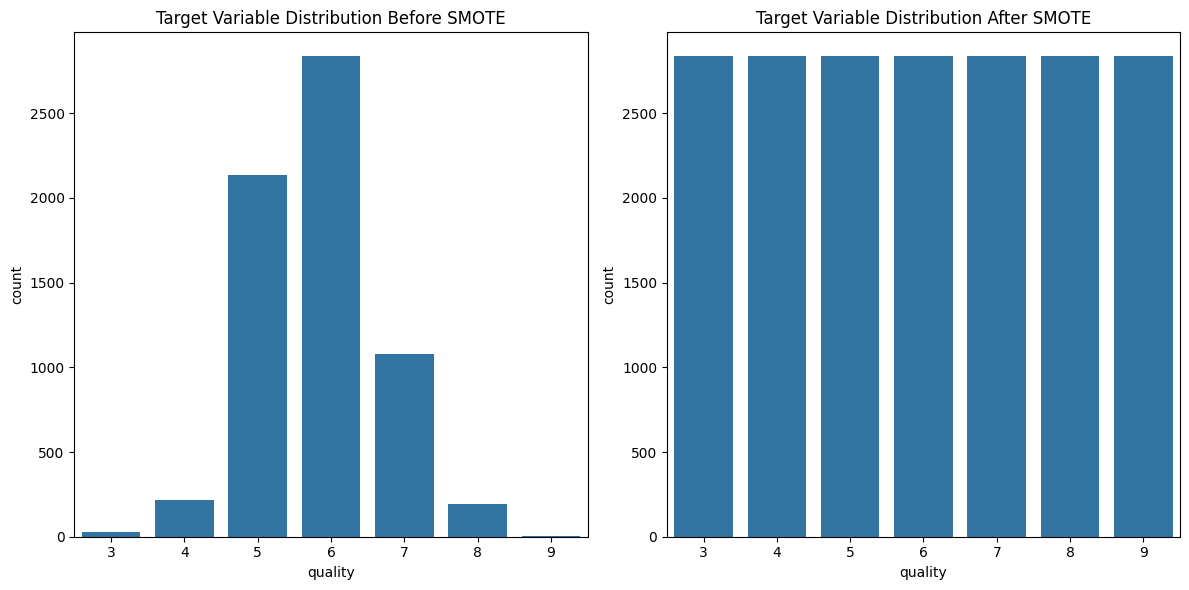

In [14]:
# Apply SMOTT to the target variable
smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Plot the target variable distribution before SMOTE
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.countplot(x=y)
plt.title('Target Variable Distribution Before SMOTE')

# Plot the target variable distribution after SMOTE
plt.subplot(1, 2, 2)
sns.countplot(x=y_resampled)
plt.title('Target Variable Distribution After SMOTE')

plt.tight_layout()
plt.show()

**Feature Extraction**

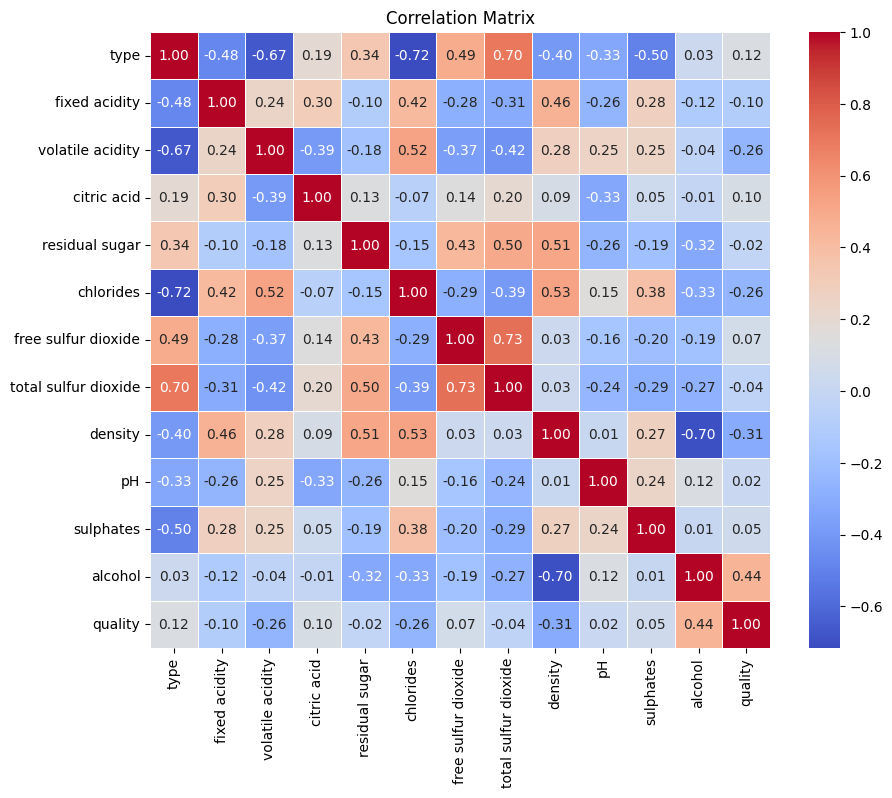

In [15]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

There is no any highly correlation values. So We can proceed without dropping any features for redundancy.

**Selection of the most suitable Model**

**k-Nearest Neighbors (KNN)** - Simple and effective for small to medium-sized datasets.

**Support Vector Machine (SVM)** - Effective for high-dimensional data and non-linear classification using kernels.

**Logistic Regression** - Baseline model to compare performance.

**Random Forest** - Handles non-linear relationships and is robust to outliers. It also gives feature importance insights.

In [16]:
# Models
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', C=1, probability=True),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

# Use KFold for cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Perform cross-validation
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_resampled, y_resampled, cv=kf, scoring='accuracy')
    results[name] = np.mean(scores)
    print(f"{name}: {np.mean(scores):.4f}")

# Identify the best model
best_model = max(results, key=results.get)
print(f"\nBest Model: {best_model} with accuracy: {results[best_model]:.4f}")

KNN: 0.8541
SVM: 0.7181
Logistic Regression: 0.4777
Random Forest: 0.9169

Best Model: Random Forest with accuracy: 0.9169


**Confusion Matrix for Random forest model**

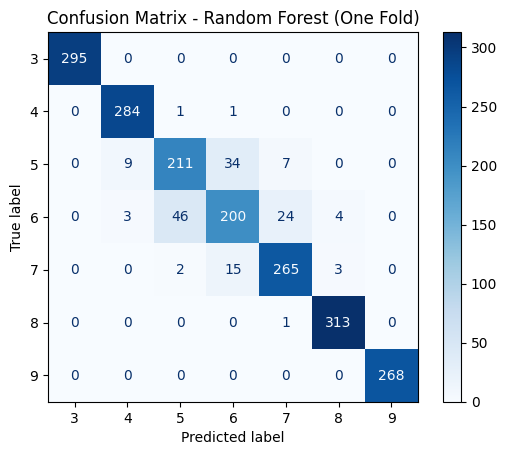

In [18]:
# Use KFold for one split to calculate and visualize the confusion matrix
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X_resampled):
    X_train, X_test = X_resampled[train_index], X_resampled[test_index]
    y_train, y_test = y_resampled[train_index], y_resampled[test_index]

    # Train the Random Forest model on this fold
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = rf_model.predict(X_test)

    # Generate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
    disp.plot(cmap=plt.cm.Blues)

    # Show the plot
    plt.title("Confusion Matrix - Random Forest (One Fold)")
    plt.show()

    break  # Visualize for only the first fold


**Let's Manually test model with sample data**

In [20]:
# Attribute Names (in order):
# [1] Type (White = 1, Red = 0), [2] Fixed Acidity, [3] Volatile Acidity,[4] Citric Acid, [5] Residual Sugar, [6] Chlorides, [7] Free Sulfur Dioxide,[8] Total Sulfur Dioxide, [9] Density, [10] pH, [11] Sulphates, [12] Alcohol

X_test_manual = np.array([
    [1, 7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4],   # Sample 1 (White wine)
    [0, 6.9, 0.6, 0.1, 2.2, 0.075, 15.0, 67.0, 0.9956, 3.19, 0.6, 10.3],   # Sample 2 (Red wine)
    [1, 7.8, 0.88, 0.0, 2.6, 0.098, 25.0, 67.0, 0.9968, 3.2, 0.68, 9.8],   # Sample 3 (White wine)
    [0, 7.0, 0.56, 0.23, 1.8, 0.063, 17.0, 28.0, 0.9962, 3.36, 0.46, 10.4], # Sample 4 (Red wine)
    [1, 6.6, 0.65, 0.02, 2.4, 0.089, 12.0, 54.0, 0.9958, 3.3, 0.56, 10.2]  # Sample 5 (White wine)
])

# Predict the wine quality for the test data
y_pred_manual = rf_model.predict(X_test_manual)

# Output predictions
print("Predicted wine quality for test samples:")
for i, prediction in enumerate(y_pred_manual, start=1):
    print(f"Sample {i}: Predicted Quality = {prediction}")

Predicted wine quality for test samples:
Sample 1: Predicted Quality = 7
Sample 2: Predicted Quality = 7
Sample 3: Predicted Quality = 6
Sample 4: Predicted Quality = 6
Sample 5: Predicted Quality = 7
